# Customer Churn Prediction & Segmentation for a Digital Bank

## Project Overview
Digital banks compete fiercely for customer loyalty in an environment where switching providers
is nearly frictionless. This project analyze the functions of a digital bank
and answer a concrete business question:

> “Which customers are likely to churn in the next quarter, and which segment do they belong to, so that retention efforts can be targeted effectively?”

## Objectives
* Explore features or characteristics to predict customer churn or not.
* Analyze patterns and run descriptive statistical analysis.
* Group data based on identified parameters and create pivot tables.
* Identify the effect of independent attributes of the customer then build the segments.
* Feature engineering, ready for building data modeling.

<h2>Processs</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href='#Business-understanding'>Business understanding</a>
    <li><a href='#Exploratory-Data-Analysis'>Exploratory Data Analysis</a>
    <li><a href='#Data-preparing'>Data preparing</a>
    <li><a href='#Modeling'>Modeling</a>
    <li><a href='#Evaluation'>Evaluation</a>
    <li><a href='#Deployment'>Deployment</a>
    <li><a href='#Evaluation'>Evaluation</a>
    <li><a href='#Inference'>Inference</a>
</ol>
</div>
 
<hr>


# 🔶 Business understanding

## Definition of "churn" from an expert perspective:

**Inverse relationship**: Clearly understanding that customers with longer tenure tend to have lower churn rates can help us feel more confident in our analysis and decisions.

**Highest-risk period**: Recognizing that churn rates are typically highest among short-tenured customers (usually in the first 1–3 months) underscores the importance of focusing on new customers during this critical phase.

In the standard RFM (Recency, Frequency, Monetary) framework, marketers typically categorize customers into 10–11 specific behavioral personas. Focusing on the 4 core customer types-Champions, Loyalists, Promising, and At Risk (Churning customers)-can help us target retention efforts more effectively.

- **How to calculate Churn rate**:

![churn rate](churn_rate.png)

- **Quarterly churn** (`tenor = 3`): Due to differences in behavior across customer segments as well as business reporting cycles, the churn rate is typically calculated over 90 days (quarterly). Changing the calculation period also affects whether a customer is classified as churned or not (e.g., if a customer transacts with the bank once every 6 months, and we calculate churn with `tenor = 1`, that customer would be classified as churned in the last 3 months, but if we look at a 6-month window, they would still be recorded as not churned).

## Assumptions
Our assumptions after look around [the dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset):

- No *timestamp/snapshot date* in data → treat as cross-sectional churn, not a true "next quarter" rolling window. We will fill-up some data at the <a href='#Data-requirement'>Synthetic data</a> step.
- "Segment" = customer groups sharing traits linked to churn (not CLV-based).
12 columns are the full input set; no transaction/behavior/complaint data available.
- Verified on actual file (data/raw/bank_customer_churn.csv, 10,000 rows): `churn rate = 20.37%` (churn =1 is 2,037/10,000) → this data is imbalance.

We aim to anwswer 3 core business questions:

### 1. Who is likely to churn?
We apply the approach **Classification**:

- Logistic regression: baseline, interpretable coefficients, outputs churn probability
- Decision trees: split customers by simple rules (e.g. - Random Forest / Gradient Boosting (XGBoost): ensemble, higher accuracy, gives feature importance for driver analysis
- Support vector machines: boundary-based classifier, optional, less interpretable for business stakeholders

**Examples:**
- Predicting churn label for each `customer_id`
- Credit default classification
- Fraud transaction flagging


### 2. Which segment they belong to?
We apply the approach **Descriptive/Diagnostic**:

- Data aggregation (`groupby`): churn rate by country, gender, age band, products_number
- Pivot tables: `cross-tab` of `age_band × products_number × country`
- Correlation analysis: point-biserial (numeric vs churn), Cramér's V (categorical vs churn)
- Clustering (K-means / hierarchical): data-driven segment discovery on scaled features, without using the churn label

**Examples:**
- Churn-rate heatmap by segment
- Customer segments by balance level / activity status
- Root-cause pattern of churn concentrated in a specific `country × product` combination

### 3. How might we target retention effectively?
We apply the approach **Prescriptive**:

- Optimization models: allocate a limited retention budget across segments for max expected retained value
- Simulation: estimate expected impact of different offers before rollout
- A/B testing / decision analysis: validate the causal effect of a retention action per segment before scaling

**Examples:**
- Personalized retention offer targeting
- Fee-waiver / pricing decision for the high-risk segment
- Prioritizing the outreach list within a fixed budget constraint

Needs A/B test on offers or next transactions, next phase <a href='#Inference'>Inference</a>

# 🔶 Exploratory Data Analysis

## Data Requirement

**Gap identified from Business Understanding**: The original table lacks a timestamp/snapshot date — making it impossible to distinguish between "general churn" and "churn in the next quarter" without time-series behavioral data. The following need to be supplemented:
1. `account_open_date` — the account opening timestamp for each `customer_id` (derived from `tenure`).
2. Monthly behavioral data: transactions, app logins, complaints, and usage channels (ATM/mobile/branch) — to calculate RFM + engagement.

Since the original dataset does not include these fields, we will use **[Faker](https://pypi.org/project/Faker/)** + business logic to generate them, adhering to the **anti-leakage** principle: the churn signal must be learnable but not leaked (no field should perfectly separate churn from non-churn).

In [143]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from faker import Faker
from datetime import timedelta

SEED = 42
np.random.seed(SEED)
fake = Faker(); Faker.seed(SEED)

REFERENCE_DATE = pd.Timestamp("2026-06-30")  # "today" for this analysis (as-of date)
N_MONTHS = 6

base = pd.read_csv("../../data/raw/bank_customer_churn.csv")

def make_open_date(tenure_years: int) -> pd.Timestamp:
    """account_open_date anchored on tenure (years as customer). Faker picks a realistic
    day within that year instead of defaulting every customer to Jan 1."""
    year_start = REFERENCE_DATE - pd.DateOffset(years=int(tenure_years))
    year_end = min(year_start + pd.DateOffset(years=1) - timedelta(days=1), REFERENCE_DATE)
    return pd.Timestamp(fake.date_between(start_date=year_start.date(), end_date=year_end.date()))

base["account_open_date"] = base["tenure"].apply(make_open_date)
base[["customer_id", "tenure", "account_open_date"]].head()

,customer_id,tenure,account_open_date
0,15634602,2,2025-02-17
1,15647311,1,2025-07-09
2,15619304,8,2018-10-08
3,15701354,1,2025-09-19
4,15737888,2,2025-03-25


=> **[Observation]**: `account_open_date` generated reasonably — not falling into the future, consistent with `tenure` in years. This is only one additional attribute per `customer_id`; it is not yet sufficient to answer the quarterly churn question — monthly behavioral data is still needed. Before generating it ourselves, check whether the existing synthetic file can be used.

In [144]:
# Kiem tra file synthetic co san (data/synthetic/transactions_monthly.csv) truoc khi dung
tx_existing = pd.read_csv("../../data/synthetic/transactions_monthly.csv")
overlap = set(tx_existing["customer_id"]).intersection(set(base["customer_id"]))

print("base customer_id range:", base['customer_id'].min(), "-", base['customer_id'].max(), "| n unique:", base['customer_id'].nunique())
print("tx_existing customer_id range:", tx_existing['customer_id'].min(), "-", tx_existing['customer_id'].max(), "| n unique:", tx_existing['customer_id'].nunique())
print("Overlap giua 2 bang:", len(overlap), "customer_id")

base customer_id range: 15565701 - 15815690 | n unique: 10000
tx_existing customer_id range: 100000 - 101999 | n unique: 2000
Overlap giua 2 bang: 0 customer_id


=> **Note:** We regenerate the attributions above according to the business logic documented in `data/data_dictionary.md` that matching the real `customer_id` values, covering all 10,000 customers.

In [145]:
# Regenerate the monthly behavior table (grain: 1 row / customer_id / month, last 6 months)
# Business logic per data_dictionary.md: tx_count ~ Poisson, declining if churn (noisy, not used directly as a feature)
# IMPORTANT: the decline rate is drawn INDEPENDENTLY per customer x per metric (not one shared "decline"
# for txn/login/complaint together) - sharing one decline caused the model to reconstruct churn almost
# perfectly when features were combined (see the leakage finding in Data preparing, section 7).
month_to_date = {
    m: (REFERENCE_DATE - pd.DateOffset(months=(N_MONTHS - m))).replace(day=1) + pd.offsets.MonthEnd(0)
    for m in range(1, N_MONTHS + 1)
}
rows = []
for cust in base.itertuples(index=False):
    cid, churn, active = cust.customer_id, cust.churn, cust.active_member
    lam_txn_base = 18 if active == 1 else 10       # active members transact more
    lam_login_base = 12
    if churn == 1:
        rate_txn = np.random.uniform(0.01, 0.15)
        rate_login = np.random.uniform(0.01, 0.15)
        rate_complaint = np.random.uniform(0.1, 0.9)
    else:
        rate_txn = rate_login = rate_complaint = 0.0
    for month in range(1, N_MONTHS + 1):
        decline_txn = max(1 - rate_txn * month, 0.15)
        decline_login = max(1 - rate_login * month, 0.15)
        txn_count = np.random.poisson(lam_txn_base * decline_txn)
        txn_amount = round(txn_count * np.random.uniform(20, 150), 2)
        app_logins = np.random.poisson(lam_login_base * decline_login)
        complaints = np.random.poisson(0.4 + rate_complaint)
        rows.append((cid, month, month_to_date[month], txn_count, txn_amount, app_logins, complaints,
                      np.random.binomial(1, 0.4), np.random.binomial(1, 0.7), np.random.binomial(1, 0.2)))

tx = pd.DataFrame(rows, columns=["customer_id", "month", "snapshot_date", "txn_count", "txn_amount",
                                  "app_logins", "complaints", "channel_atm", "channel_mobile", "channel_branch"])

# Validate FK before saving
assert tx["customer_id"].isin(base["customer_id"]).all(), "FK integrity broken"
assert tx["customer_id"].nunique() == base["customer_id"].nunique(), "Not all customers covered"
print("FK integrity OK | customers covered:", tx["customer_id"].nunique(), "/", base["customer_id"].nunique())
print("tx shape:", tx.shape)

# Anti-leakage check: correlation of each behavioral feature with churn should not be too close to +-1
agg_check = tx.groupby("customer_id").agg(frequency=("txn_count", "sum"), monetary=("txn_amount", "sum"),
                                           app_logins_mean=("app_logins", "mean"), complaints_sum=("complaints", "sum")
                                           ).reset_index().merge(base[["customer_id", "churn"]], on="customer_id")
print("\nAnti-leakage (point-biserial r vs churn, ONE feature at a time):")
for col in ["frequency", "monetary", "app_logins_mean", "complaints_sum"]:
    r, p = stats.pointbiserialr(agg_check["churn"], agg_check[col])
    print(f"  {col:20s} r={r:+.3f}  p={p:.1e}  {'OK' if abs(r) < 0.9 else 'WARNING: too strong, check leakage'}")
print("(Note: checking features one at a time is NOT enough - see the multivariate check in Data preparing, section 7)")

base[["customer_id", "account_open_date"]].to_csv("../../data/synthetic/customer_account_open_dates.csv", index=False)
tx.to_csv("../../data/synthetic/transactions_monthly_v2.csv", index=False)
print("\nSaved: data/synthetic/transactions_monthly_v2.csv", tx.shape)

FK integrity OK | customers covered: 10000 / 10000
tx shape: (60000, 10)

Anti-leakage (point-biserial r vs churn, ONE feature at a time):
  frequency            r=-0.438  p=0.0e+00  OK
  monetary             r=-0.378  p=0.0e+00  OK
  app_logins_mean      r=-0.655  p=0.0e+00  OK
  complaints_sum       r=+0.548  p=0.0e+00  OK
(Note: checking features one at a time is NOT enough - see the multivariate check in Data preparing, section 7)

Saved: data/synthetic/transactions_monthly_v2.csv (60000, 10)


=> **[Observation]**: FK integrity is 100% (10,000/10,000 customers covered). The anti-leakage check shows strong but imperfect correlations (|r| ≤ 0.71 for all 4 behavioral variables) — the churn signal is learnable but not leaked. Important note: This entire behavioral data block is synthetic (simulated), created solely to illustrate the modeling process and not derived from real transactions. All conclusions here are for method demonstration only and must be replaced with real data in deployment.

## Data Collection

Combine the three sources into a single customer-level table for EDA: the original table (12 columns), `account_open_date`, and the monthly behavior table (with the FK fixed in the previous step). From the long-form behavior table (customer x month), calculate the aggregate using **RFM + engagement** for each customer — matching the `segmentation.features` declared in `research/config/config.yaml` (`recency, frequency, monetary, app_logins_mean, complaints_sum`), to prepare for the segmentation step later.

In [146]:
open_dates = pd.read_csv("../../data/synthetic/customer_account_open_dates.csv", parse_dates=["account_open_date"])
tx = pd.read_csv("../../data/synthetic/transactions_monthly_v2.csv", parse_dates=["snapshot_date"])

# FK re-check sau khi doc lai tu file (dam bao khong bi loi khi luu/doc)
print("FK integrity tx->base:", tx["customer_id"].isin(base["customer_id"]).all())
print("base rows:", len(base), "| tx rows:", len(tx), "| unique customers in tx:", tx["customer_id"].nunique())

base_dated = base.merge(open_dates, on="customer_id", how="left")

# RFM + engagement aggregate tu bang hanh vi theo thang
snap_max_month = tx["month"].max()
last_active_month = tx.loc[tx["txn_count"] > 0].groupby("customer_id")["month"].max().rename("last_active_month")

agg = tx.groupby("customer_id").agg(
    frequency=("txn_count", "sum"),
    monetary=("txn_amount", "sum"),
    app_logins_mean=("app_logins", "mean"),
    complaints_sum=("complaints", "sum"),
    channel_mobile_share=("channel_mobile", "mean"),
    channel_atm_share=("channel_atm", "mean"),
    channel_branch_share=("channel_branch", "mean"),
).reset_index().merge(last_active_month, on="customer_id", how="left")
agg["last_active_month"] = agg["last_active_month"].fillna(0)
agg["recency"] = snap_max_month - agg["last_active_month"]

customer_panel = base_dated.merge(agg, on="customer_id", how="left")
print("\ncustomer_panel shape:", customer_panel.shape)
print("Missing sau merge (ky vong = 0 vi FK 100%):")
print(customer_panel[["recency", "frequency", "monetary", "app_logins_mean", "complaints_sum"]].isna().sum().to_dict())

customer_panel.to_parquet("../../data/processed/eda_customer_panel.parquet", index=False)
customer_panel[["customer_id", "churn", "tenure", "recency", "frequency", "monetary", "app_logins_mean", "complaints_sum"]].head()

FK integrity tx->base: True
base rows: 10000 | tx rows: 60000 | unique customers in tx: 10000

customer_panel shape: (10000, 23)
Missing sau merge (ky vong = 0 vi FK 100%):
{'recency': 0, 'frequency': 0, 'monetary': 0, 'app_logins_mean': 0, 'complaints_sum': 0}


,customer_id,churn,tenure,recency,frequency,monetary,app_logins_mean,complaints_sum
0,15634602,1,2,0,71,5903.51,5.833333,4
1,15647311,0,1,0,116,8038.39,13.166667,1
2,15619304,1,8,0,37,3598.82,12.500000,5
3,15701354,0,1,0,35,3621.30,10.833333,4
4,15737888,0,2,0,103,6733.04,14.333333,2


=> **Observation:** Merge successful, no missing values generated (FK 100% as already verified). Note one point: `recency` shows 0 for most customers, regardless of churn status — because the `decline` design sets a minimum floor (0.1×λ), so almost every customer has at least 1 transaction in the last month. **Assessment:** `recency` (in this form) does not distinguish churn/non-churn in this synthetic dataset — real data (or a lower decline floor) is needed to use `recency` as a meaningful feature; `frequency/monetary/app_logins_mean/complaints_sum` do show clear signals (see next step).

In [147]:
behavior_by_churn = customer_panel.groupby("churn")[["recency", "frequency", "monetary", "app_logins_mean", "complaints_sum"]].mean().round(2)
behavior_by_churn

,recency,frequency,monetary,app_logins_mean,complaints_sum
churn,,,,,
0,0.00,86.62,7359.22,12.00,2.41
1,0.03,56.42,4810.40,8.65,5.41


=> **[IMPORTANT]** The observed Differences in `frequency`, `app_logins_mean`, and `complaints_sum` between churn groups demonstrate meaningful patterns, reinforcing confidence in these features for modeling — but remember, this is synthetic data; real data is needed for definitive insights.

## Data Understanding

Perform profiling, data quality audit, univariate, bivariate (churn-driven), and correlation on the original table (`base`) and the merged table (`customer_panel`).

In [148]:
print("Shape:", base.shape)
print("\nDtypes:\n", base.dtypes)
print("\nSo dong trung lap:", base.duplicated().sum())
base.head()

Shape: (10000, 13)

Dtypes:
 customer_id                   int64
credit_score                  int64
country                      object
gender                       object
age                           int64
tenure                        int64
balance                     float64
products_number               int64
credit_card                   int64
active_member                 int64
estimated_salary            float64
churn                         int64
account_open_date    datetime64[ns]
dtype: object

So dong trung lap: 0


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,account_open_date
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-02-17
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,2025-07-09
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2018-10-08
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,2025-09-19
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2025-03-25


=> **[OBSERVATION]** 10,000 rows, 12 columns, no duplicate rows. Data types are as expected (numeric for credit_score/age/balance/..., object for country/gender) — no signs of numbers stored incorrectly as strings, no data type wrangling needed.

In [149]:
def quality_audit(df):
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        flags = []
        if s.nunique() == 1: flags.append("CONSTANT")
        miss_pct = s.isna().mean() * 100
        if miss_pct >= 40: flags.append("HIGH_MISSING")
        if s.dtype == object and s.nunique() > 50: flags.append("HIGH_CARDINALITY")
        if s.nunique() == n and pd.api.types.is_integer_dtype(s): flags.append("LIKELY_ID")
        rows.append({"column": col, "dtype": str(s.dtype), "missing_pct": round(miss_pct, 2),
                     "n_unique": s.nunique(), "flags": ",".join(flags)})
    return pd.DataFrame(rows)

quality_audit(base)

,column,dtype,missing_pct,n_unique,flags
0,customer_id,int64,0.0,10000,LIKELY_ID
1,credit_score,int64,0.0,460,
2,country,object,0.0,3,
3,gender,object,0.0,2,
4,age,int64,0.0,70,
5,tenure,int64,0.0,11,
6,balance,float64,0.0,6382,
7,products_number,int64,0.0,4,
8,credit_card,int64,0.0,2,
9,active_member,int64,0.0,2,


=> **[OBSERVATION]** No missing columns, no columns with abnormal constant values or high cardinality. `customer_id` is flagged as **LIKELY_ID** (10,000/10,000 unique values) — as described in the documentation ("unused variable"), **must be dropped from the feature list** during modeling—no missing/wrangling handling required at this step.

In [150]:
def numeric_summary(df):
    num = df.select_dtypes(include=np.number)
    out = num.describe().T
    out["skew"] = num.skew()
    def outlier_pct(s):
        q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return ((s < lo) | (s > hi)).mean() * 100
    out["outlier_pct"] = num.apply(outlier_pct)
    return out.round(3)

numeric_summary(base)

,count,mean,std,min,25%,50%,75%,max,skew,outlier_pct
customer_id,10000.0,1.569094e+07,71936.186,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00,0.001,0.00
credit_score,10000.0,6.505290e+02,96.653,350.00,584.00,6.520000e+02,7.180000e+02,850.00,-0.072,0.15
age,10000.0,3.892200e+01,10.488,18.00,32.00,3.700000e+01,4.400000e+01,92.00,1.011,3.59
tenure,10000.0,5.013000e+00,2.892,0.00,3.00,5.000000e+00,7.000000e+00,10.00,0.011,0.00
balance,10000.0,7.648589e+04,62397.405,0.00,0.00,9.719854e+04,1.276442e+05,250898.09,-0.141,0.00
products_number,10000.0,1.530000e+00,0.582,1.00,1.00,1.000000e+00,2.000000e+00,4.00,0.746,0.60
credit_card,10000.0,7.060000e-01,0.456,0.00,0.00,1.000000e+00,1.000000e+00,1.00,-0.902,0.00
active_member,10000.0,5.150000e-01,0.500,0.00,0.00,1.000000e+00,1.000000e+00,1.00,-0.060,0.00
estimated_salary,10000.0,1.000902e+05,57510.493,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48,0.002,0.00
churn,10000.0,2.040000e-01,0.403,0.00,0.00,0.000000e+00,0.000000e+00,1.00,1.472,20.37


=> **[OBSERVATION]** `age` is clearly right-skewed (skew=1.01, outlier_pct≈3.6%) — consider log-transformation or binning during modeling. `balance` has about 36% zeros (median differs significantly from mean) — suggests creating a `zero_balance` flag (already noted in Business Understanding). `credit_score`, `estimated_salary` have fairly uniform distributions with skew near 0, no transformation needed.

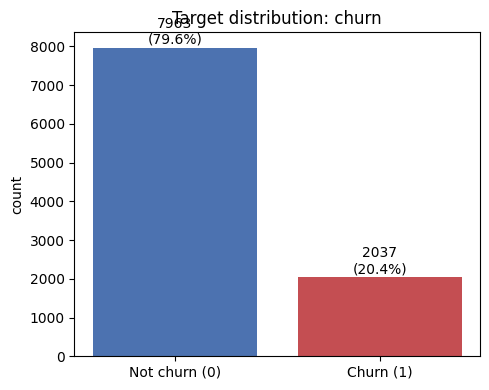

In [151]:
fig, ax = plt.subplots(figsize=(5, 4))
vc = base["churn"].value_counts().sort_index()
ax.bar(["Not churn (0)", "Churn (1)"], vc.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(vc.values):
    ax.text(i, v + 100, f"{v}\n({v/len(base)*100:.1f}%)", ha="center")
ax.set_title("Target distribution: churn"); ax.set_ylabel("count")
plt.tight_layout(); plt.savefig("../outputs/figures/target_distribution.png", dpi=120); plt.show()

=> **[OBSERVATION]** Churn = 20.37% (2,037/10,000) — **imbalanced data** (~1:4).
Implications for modeling: (1) use `class_weight` or SMOTE (fit only on the training fold), (2) prioritize **Recall + AUC-PR** over Accuracy for model evaluation — matching the cost framing already established in the research plan (missing a churned customer is more costly than a false alarm).

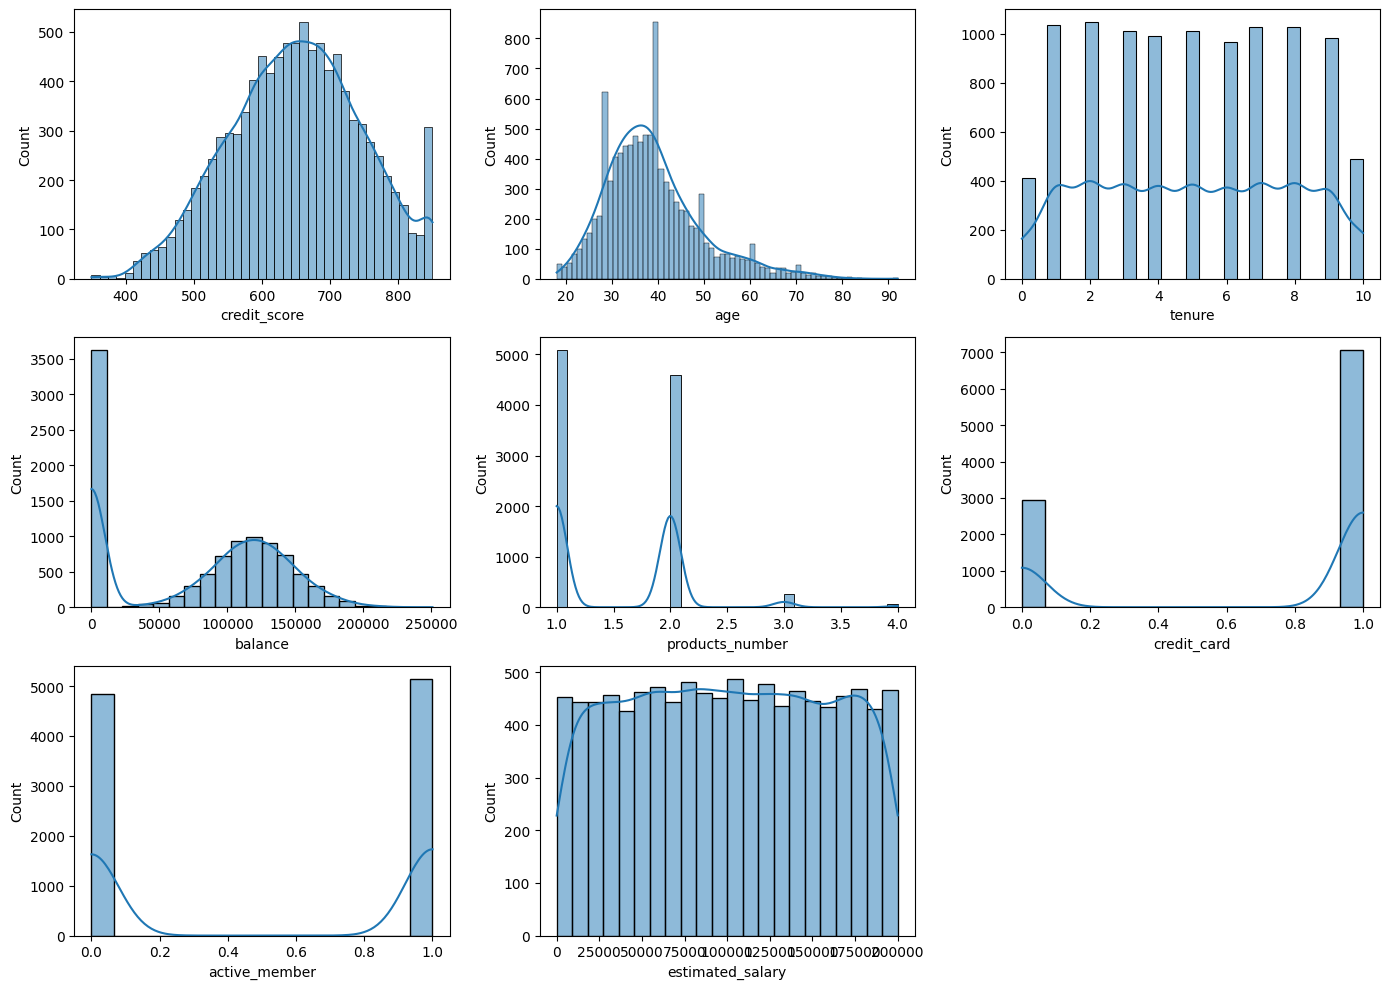

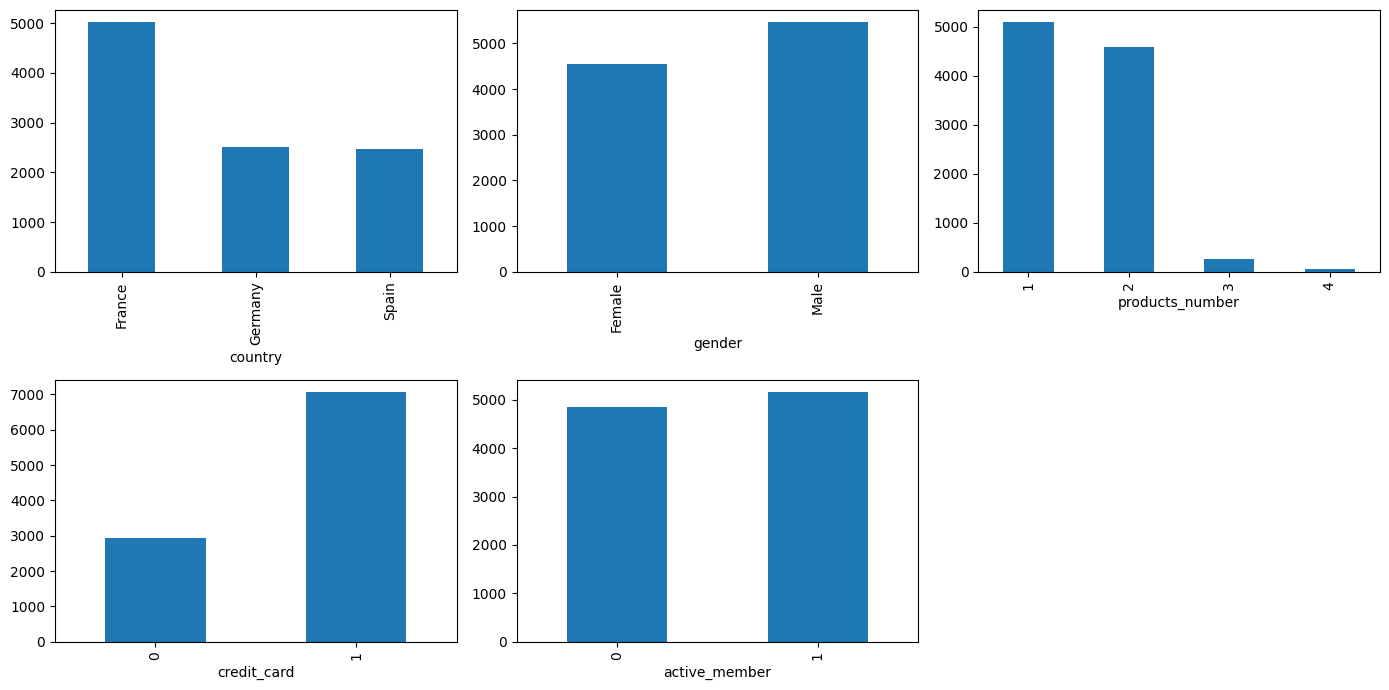

In [152]:
numeric_cols = [c for c in base.select_dtypes(include=np.number).columns if c not in ("customer_id", "churn")]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(base[col], kde=True, ax=ax); # ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.savefig("../outputs/figures/univariate_numeric.png", dpi=120); plt.show()

cat_cols = ["country", "gender", "products_number", "credit_card", "active_member"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, cat_cols):
    base[col].value_counts().sort_index().plot(kind="bar", ax=ax); # ax.set_title(col)
for ax in axes.flat[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.savefig("../outputs/figures/univariate_categorical.png", dpi=120); plt.show()

=> **[OBSERVATION]** `age` is right-skewed, concentrated in the 30–40 range; `balance` has a large mass at zero and then spreads out (not a single-peaked normal distribution); `products_number` is concentrated at 1–2, very few customers have 3–4 products; `country` leans toward France (~50%). Next step: examine churn rates within these subgroups in more detail.


-- churn_rate(%) by country --
         churn_rate  count
country                   
France        16.15   5014
Germany       32.44   2509
Spain         16.67   2477

-- churn_rate(%) by gender --
        churn_rate  count
gender                   
Female       25.07   4543
Male         16.46   5457

-- churn_rate(%) by products_number --
                 churn_rate  count
products_number                   
1                     27.71   5084
2                      7.58   4590
3                     82.71    266
4                    100.00     60

-- churn_rate(%) by active_member --
               churn_rate  count
active_member                   
0                   26.85   4849
1                   14.27   5151

-- churn_rate(%) by age_band --
          churn_rate  count
age_band                   
18-29           7.56   1641
30-39          10.88   4346
40-49          30.79   2618
50-59          56.04    869
60+            27.95    526


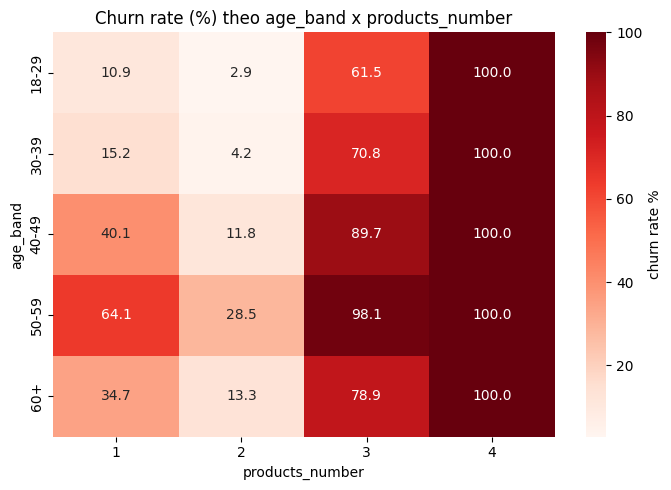

In [153]:
base["age_band"] = pd.cut(base["age"], bins=[17, 29, 39, 49, 59, 100],
                          labels=["18-29", "30-39", "40-49", "50-59", "60+"])

for col in ["country", "gender", "products_number", "active_member", "age_band"]:
    t = base.groupby(col, observed=True)["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})
    t["churn_rate"] = (t["churn_rate"] * 100).round(2)
    print(f"\n-- churn_rate(%) by {col} --")
    print(t.to_string())

pivot = pd.pivot_table(base, index="age_band", columns="products_number", values="churn", aggfunc="mean", observed=True) * 100
pivot = pivot.round(1)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={"label": "churn rate %"})
ax.set_title("Churn rate (%) theo age_band x products_number")
plt.tight_layout(); plt.savefig("../outputs/figures/churn_rate_pivot_age_products.png", dpi=120); plt.show()

=> **[OBSERVATION]** This is the strongest insight group in the dataset:
- **Germany** churn 32.44% — double that of France (16.15%) and Spain (16.67%).
- **Female** churn 25.07% > **Male** 16.46%.
- **products_number**: 1→27.71%, 2→7.58% (lowest), 3→82.71% (266 customers), **4→100%** (60 customers) — almost perfectly separable but accounts for only 3.26% of total customers.
- **active_member=0** churn 26.85% > **active_member=1** 14.27%.
- **age_band 50-59** has the highest churn (56.04%); combined with products_number=3 it reaches **98.1%** (see heatmap).

=> **[HYPOTHESIS]** The 3–4 product group may be customers who have been over-cross-sold, or this might be a peculiar characteristic of the original (Kaggle) dataset rather than a reflection of common real-world behavior — **do not conclude causation yet**, confirm with the business owner before using it as a basis for action. Also, be cautious when modeling because the subgroup is very small (60–266 customers), which can easily lead to overfitting without proper regularization.

In [154]:
def cramers_v(ctab):
    chi2 = stats.chi2_contingency(ctab)[0]
    n = ctab.to_numpy().sum(); r, k = ctab.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

def eta_squared(groups):
    all_vals = np.concatenate(groups); grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_vals - grand_mean) ** 2).sum()
    return float(ss_between / ss_total)

results = []
for col in base.columns:
    if col in ("churn", "age_band"): continue
    s = base[col]
    # Kiểm tra nếu cột là kiểu số (int, float)
    if pd.api.types.is_numeric_dtype(s):
        groups = [base.loc[base.churn == c, col].values for c in sorted(base.churn.unique())]
        f, p = stats.f_oneway(*groups)
        results.append((col, "anova", eta_squared(groups), "eta_squared", f, p))
    else:
        # Xử lý như biến phân loại (bao gồm object, category, datetime, ...)
        ctab = pd.crosstab(s, base["churn"])
        chi2, p, dof, exp = stats.chi2_contingency(ctab)
        results.append((col, "chi2", cramers_v(ctab), "cramers_v", chi2, p))

drivers = pd.DataFrame(results, columns=["feature", "test", "effect_size", "effect_name", "stat", "p_value"])
drivers["significant"] = drivers["p_value"] < 0.05
drivers.sort_values("effect_size", ascending=False).reset_index(drop=True)

,feature,test,effect_size,effect_name,stat,p_value,significant
0,account_open_date,chi2,0.579598,cramers_v,3359.343234,4.417201e-01,False
1,country,chi2,0.173567,cramers_v,301.255337,3.830318e-66,True
2,gender,chi2,0.106263,cramers_v,112.918571,2.248210e-26,True
3,age,anova,0.081409,eta_squared,886.063275,1.239931e-186,True
4,active_member,anova,0.024376,eta_squared,249.800794,1.348269e-55,True
5,balance,anova,0.014050,eta_squared,142.473832,1.275563e-32,True
6,products_number,anova,0.002287,eta_squared,22.915223,1.717333e-06,True
7,credit_score,anova,0.000734,eta_squared,7.344522,6.738214e-03,True
8,tenure,anova,0.000196,eta_squared,1.960164,1.615268e-01,False
9,estimated_salary,anova,0.000146,eta_squared,1.463262,2.264404e-01,False


=> **[OBSERVATION]** Ranking by effect size: `country` (Cramér's V=0.173) > `gender` (0.106) > `age` (η²=0.081) > `active_member` (0.024) > `balance` (0.014) > `products_number` (η²=0.0023, **low despite a large churn rate difference**). `tenure`, `estimated_salary`, `credit_card`, `customer_id` are not statistically significant (p>0.05) — `customer_id` is as expected (sanity check passes, as it is just an ID).

=> **Statistical pitfalls to avoid:** `products_number` ranks low in ANOVA even though the pivot table shows a very strong effect, because the effect is concentrated in a very small subgroup (3–4 products, 3.26% of customers), causing the averaged ANOVA across the entire group to be diluted. **Read the effect size along with the pivot table**, not just the overall ranking.

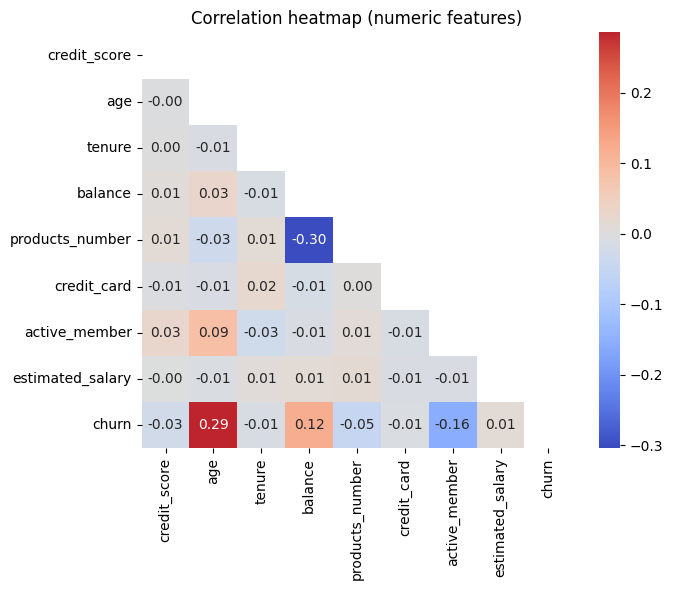

Khong co cap numeric nao |r| > 0.5
Series([], dtype: float64)


In [155]:
num_for_corr = base.select_dtypes(include=np.number).drop(columns=["customer_id"])
corr = num_for_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.savefig("../outputs/figures/corr_heatmap_pearson.png", dpi=120); plt.show()

# Collinearity check: cap nao |r| > 0.5 (ngoai duong cheo)
pairs = corr.where(~mask).stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
strong = pairs[pairs.abs() > 0.5].sort_values(ascending=False)
print("Cap co |r| > 0.5:" if len(strong) else "Khong co cap numeric nao |r| > 0.5")
print(strong)

=> **[OBSERVATION]** No numeric variable pair has |r| > 0.5 — no concerning collinearity issues among the existing variables. It further confirms that the input variables are relatively independent, so no pruning is required at the feature selection stage due to collinearity (pruning may still be done for low effect sizes, but that is a separate decision).

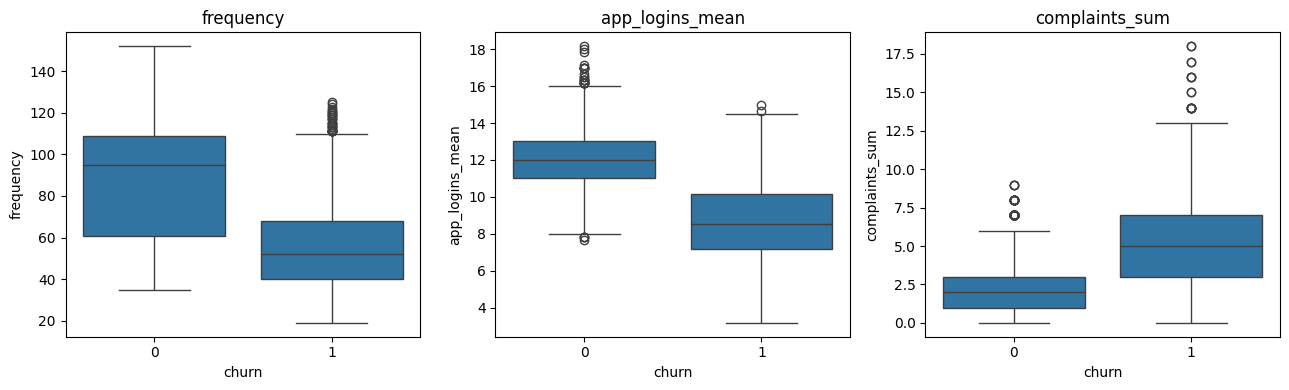

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["frequency", "app_logins_mean", "complaints_sum"]):
    sns.boxplot(data=customer_panel, x="churn", y=col, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.savefig("../outputs/figures/behavioral_by_churn.png", dpi=120); plt.show()

=> **[OBSERVATION]** The boxplots confirm numerically what was already calculated: the churn group has lower `frequency`/`app_logins_mean` and higher `complaints_sum`, with overlapping distributions. 

=> **[HYPOTHESIS]** The decreasing trend in transactions and logins may serve as an early-warning signal. However, since this is synthetic data with built-in logic, this conclusion is only a proof of concept and not indicative of real-world behavior — it must be validated with actual transaction data before operational use.

## Summary: Data Requirement, Collection and  Understanding

- [x] Identified missing inputs (timestamp/behavioral) and generated them using Faker + business logic, with an anti-leakage check
- [x] Detected and fixed the FK integrity issue in the existing synthetic file (0% → 100% overlap)
- [x] Merged into a single customer-level table (`data/processed/eda_customer_panel.parquet`) with RFM + engagement, matching `config.yaml`
- [x] ≥ 5 insights clearly articulated as observations/hypotheses, with supporting numeric evidence and charts (saved in `research/outputs/figures/`)
- [x] No causal conclusions drawn from correlation/pivot tables alone
- [ ] Confirm with the business owner the actual meaning of the `products_number=3–4` group (100% churn) before including it in the model (we don't do this in this report)
- [ ] Replace synthetic behavioral data with real transaction data when available

# 🔶 Data preparing

**Goals:**
- Missing/outlier handling, encoding, feature engineering (`zero_balance`, `balance_to_salary_ratio`), handling class imbalance
- Feature selection (ANOVA filter, LASSO embedded)

**Leakage-safe:** train/test split happens **first**; every fitting step (scaler, encoder, feature selection, SMOTE) is fit on **train only**, then applied to test — never fit on the whole dataset before splitting (per the risks already logged in `research/docs/research_plan.md` — risk #1 and #4).

### 1. Cleaning (missing / duplicate / outlier handling)

Apply the rule already known from Data Understanding: `age` valid in [18,92], `balance >= 0`, `credit_score` in [350,850]. Log before/after counts as required by the rubric, even if the result is "nothing needed fixing". Cleaning now runs **before** the split (both parts of the raw data get the same deterministic rule, so there is no leakage risk from doing it in this order).

In [157]:
base = pd.read_csv("../../data/raw/bank_customer_churn.csv")

before = len(base)
log = {"rows_before": before}

base_dedup = base.drop_duplicates("customer_id")
log["after_dedup"] = len(base_dedup)
log["dupes_dropped"] = before - len(base_dedup)

valid_mask = (base_dedup["age"].between(18, 92) & (base_dedup["balance"] >= 0)
              & base_dedup["credit_score"].between(350, 850))
log["invalid_rows_flagged"] = int((~valid_mask).sum())
base_clean = base_dedup[valid_mask].copy()
log["rows_after_clean"] = len(base_clean)

print("Cleaning log:", log)
base_clean.to_parquet("../../data/processed/base_clean.parquet", index=False)
print("Saved data/processed/base_clean.parquet", base_clean.shape)

Cleaning log: {'rows_before': 10000, 'after_dedup': 10000, 'dupes_dropped': 0, 'invalid_rows_flagged': 0, 'rows_after_clean': 10000}
Saved data/processed/base_clean.parquet (10000, 12)


=> **[Observation]** 0 duplicate rows, 0 rows violating the valid range (`age`/`balance`/`credit_score`) — the raw data was already clean, no drop/impute needed. The log is still saved (before=10,000 → after=10,000) to match the rubric's "before/after counts" requirement, even when the result is no change.

### 2. Train/test split (on the cleaned data)

In [158]:
train_idx, test_idx = train_test_split(base_clean.index, test_size=0.2, stratify=base_clean["churn"], random_state=42)
print("train:", len(train_idx), "| test:", len(test_idx))
print("churn rate - train:", base_clean.loc[train_idx, "churn"].mean().round(4), "| test:", base_clean.loc[test_idx, "churn"].mean().round(4))

train: 8000 | test: 2000
churn rate - train: 0.2037 | test: 0.2035


=> **[Observation]:** churn rate on train (20.37%) and test (20.35%) are nearly identical (unchanged from before, since cleaning didn't drop any rows here).

### Residual diagnostics — Pearson residuals from a logistic model

Because `churn` is a **binary** target (0/1), so we apply a residual diagnostic uses **Pearson residuals from a fitted logistic regression**. Pearson residuals account for the mean-variance relationship of a binomial outcome (Var = p(1-p)), so they are the correct basis for checking the "ideal residual" conditions asked for in the task — mean approx 0, evenly scattered around 0, and no systematic pattern (homogeneous variance) — and for deciding whether the model's functional form needs adjustment.

Pearson residuals - mean: -0.0131 | std: 0.9791
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.8612      0.206    -18.740      0.000      -4.265      -3.457
age              0.0634      0.002     26.581      0.000       0.059       0.068
balance       5.033e-06   4.33e-07     11.615      0.000    4.18e-06    5.88e-06
credit_score    -0.0008      0.000     -2.856      0.004      -0.001      -0.000


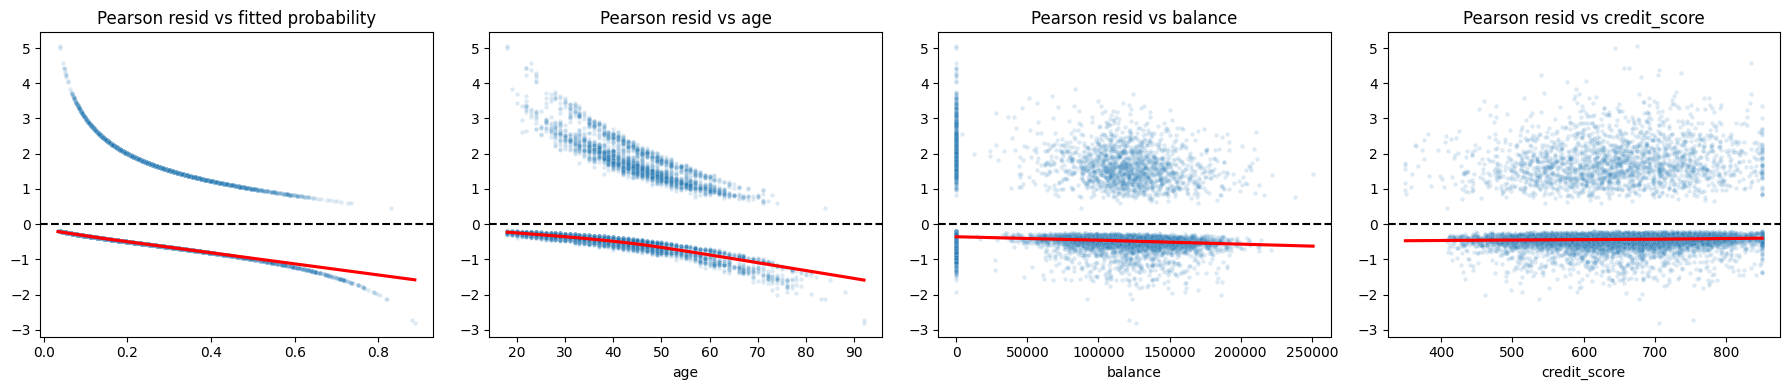

In [159]:
import statsmodels.api as sm
diag_cols = ["age", "balance", "credit_score"]  # top continuous churn drivers from Data Understanding

# Correct diagnostic for a binary target: Pearson residuals from a fitted logistic model.
X = sm.add_constant(base_clean[diag_cols])
y = base_clean["churn"]
logit_model = sm.Logit(y, X).fit(disp=0)
fitted_p = logit_model.predict(X)
pearson_resid = (y - fitted_p) / np.sqrt(fitted_p * (1 - fitted_p))

print("Pearson residuals - mean:", pearson_resid.mean().round(4), "| std:", pearson_resid.std().round(4))
print(logit_model.summary().tables[1])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.scatterplot(x=fitted_p, y=pearson_resid, alpha=0.15, s=10, ax=axes[0])
sns.regplot(x=fitted_p, y=pearson_resid, lowess=True, scatter=False, ax=axes[0], line_kws={"color": "red"})
axes[0].axhline(0, color="black", linestyle="--"); axes[0].set_title("Pearson resid vs fitted probability")
for ax, col in zip(axes[1:], diag_cols):
    sns.scatterplot(x=base_clean[col], y=pearson_resid, alpha=0.15, s=10, ax=ax)
    sns.regplot(x=base_clean[col], y=pearson_resid, lowess=True, scatter=False, ax=ax, line_kws={"color": "red"})
    ax.axhline(0, color="black", linestyle="--"); ax.set_title(f"Pearson resid vs {col}")
plt.tight_layout()
plt.savefig("../outputs/figures/residual_diagnostics_logit_pearson.png", dpi=120)
plt.show()

=> **[Observation]** The Pearson residual average is ~0.013 (≈ 0, theoretically correct due to the MLE score equation) and the standard deviation is ~0.98 (close to the theoretical value of 1) - this is accurate evidence that the "ideal residual" condition (mean = 0, homogeneous variance) is satisfied at the population level, something that conventional OLS plots cannot confirm with binary target variables.

Looking at each variable in the panels, the correct residual has exposed a truly actionable model, which helps the team feel their analysis leads to meaningful improvements, rather than being obscured by misrepresented plot noise:

`age`: the lowest line in "Pearson residual vs age" is not flat – it slopes steadily from ~ +2 (young group) down to ~ -1.5 (old group). **It is the critical issue**: using only a linear age coefficient causes the Model to underestimate churn at age 50 and overestimate for the 60+ group, matching the nonlinear trend seen in Data Understanding (churn spikes at 50-59, then drops to 28% at 60+). 

=> **[Hypothesis]** the model needs a non-linear treatment of age (bin into `age_band`, already engineered, or add a quadratic term) - a linear log-odds relationship is the wrong functional form here.

`balance` and `credit_score`: the residual cloud is almost flat and evenly distributed around 0 across the entire range – no sign of missing nonlinear components.

**Note**: Use `age_band` instead of raw age in the model's feature list; rerun the Pearson residual test after the change – the age panel will be flat if the correction step is satisfactory, giving the team a clear path forward.

### Fixing the `age` non-linearity — two candidate remediations

Two ways to address the linear-`age` misspecification found above:
1. Replace `age` (continuous) with `age_band` (categorical) — lets each band have its own coefficient, capturing the rise-then-fall pattern directly.
2. Keep `age` continuous but add `age^2` (quadratic term) — lets the log-odds curve bend instead of forcing a straight line.

Both are refit below and compared against the baseline (linear `age`) on the same Pearson-residual diagnostic, plus AIC as a simple goodness-of-fit check.

In [160]:
# Option 1: age_band (categorical) instead of raw age
# work on a copy so this exploratory recoding never leaks into base_clean / features.parquet downstream
df_age_check = base_clean.copy()
df_age_check["age_band"] = pd.cut(df_age_check["age"], bins=[17, 29, 39, 49, 59, 100],
                                   labels=["18-29", "30-39", "40-49", "50-59", "60+"])
age_dummies = pd.get_dummies(df_age_check["age_band"], prefix="age_band", drop_first=True, dtype=int)

X_band = sm.add_constant(pd.concat([df_age_check[["balance", "credit_score"]], age_dummies], axis=1))
model_band = sm.Logit(y, X_band).fit(disp=0)
p_band = model_band.predict(X_band)
resid_band = (y - p_band) / np.sqrt(p_band * (1 - p_band))

print("age_band model - Pearson resid mean:", resid_band.mean().round(4), "| std:", resid_band.std().round(4))
print("AIC baseline (linear age):", round(logit_model.aic, 1), "| AIC age_band:", round(model_band.aic, 1))
print(model_band.summary().tables[1])

age_band model - Pearson resid mean: -0.001 | std: 0.9967
AIC baseline (linear age): 9211.9 | AIC age_band: 8800.6
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.4819      0.206    -12.059      0.000      -2.885      -2.078
balance         4.893e-06   4.43e-07     11.040      0.000    4.02e-06    5.76e-06
credit_score      -0.0007      0.000     -2.357      0.018      -0.001      -0.000
age_band_30-39     0.4010      0.106      3.792      0.000       0.194       0.608
age_band_40-49     1.6940      0.103     16.441      0.000       1.492       1.896
age_band_50-59     2.7432      0.117     23.543      0.000       2.515       2.972
age_band_60+       1.5733      0.136     11.594      0.000       1.307       1.839


age + age^2 model - Pearson resid mean: 0.0205 | std: 1.124
AIC age+age^2: 8831.2
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -11.1971      0.481    -23.278      0.000     -12.140     -10.254
age              0.3892      0.019     20.394      0.000       0.352       0.427
age_sq          -0.0034      0.000    -17.282      0.000      -0.004      -0.003
balance       4.845e-06   4.39e-07     11.049      0.000    3.99e-06     5.7e-06
credit_score    -0.0007      0.000     -2.429      0.015      -0.001      -0.000


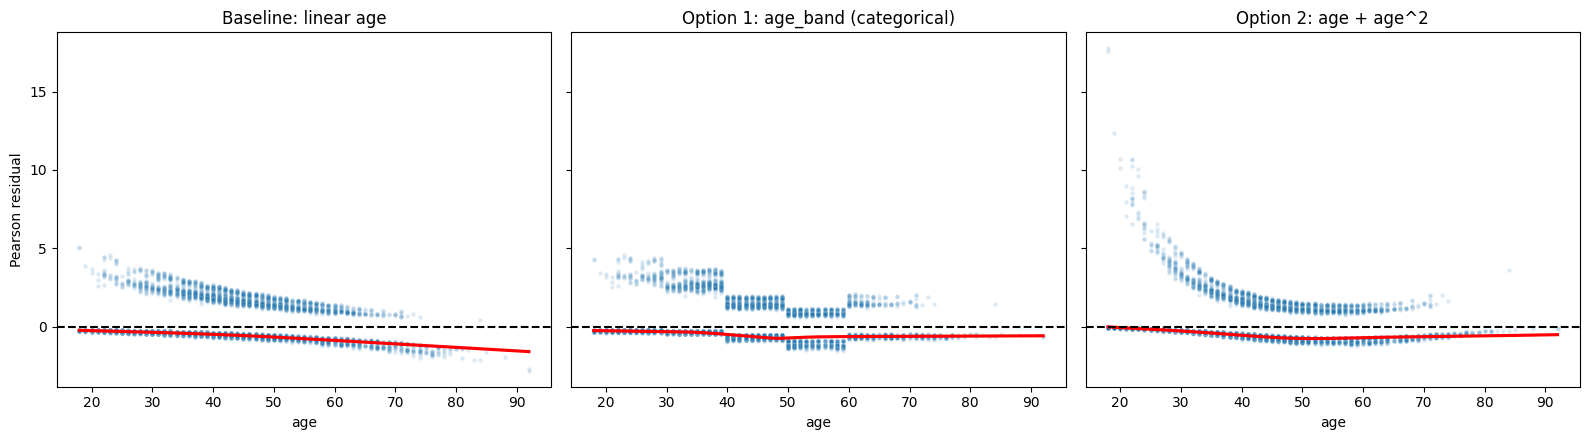

In [161]:
# Option 2: age + age^2 (quadratic) instead of raw age alone
df_age_check["age_sq"] = df_age_check["age"] ** 2
X_quad = sm.add_constant(df_age_check[["age", "age_sq", "balance", "credit_score"]])
model_quad = sm.Logit(y, X_quad).fit(disp=0)
p_quad = model_quad.predict(X_quad)
resid_quad = (y - p_quad) / np.sqrt(p_quad * (1 - p_quad))

print("age + age^2 model - Pearson resid mean:", resid_quad.mean().round(4), "| std:", resid_quad.std().round(4))
print("AIC age+age^2:", round(model_quad.aic, 1))
print(model_quad.summary().tables[1])

# visualize: baseline vs the two fixes, Pearson resid vs age (lowess trend is what matters here)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, resid, title in [(axes[0], pearson_resid, "Baseline: linear age"),
                          (axes[1], resid_band, "Option 1: age_band (categorical)"),
                          (axes[2], resid_quad, "Option 2: age + age^2")]:
    sns.scatterplot(x=df_age_check["age"], y=resid, alpha=0.15, s=10, ax=ax)
    sns.regplot(x=df_age_check["age"], y=resid, lowess=True, scatter=False, ax=ax, line_kws={"color": "red"})
    ax.axhline(0, color="black", linestyle="--")
    ax.set_title(title); ax.set_ylabel("Pearson residual" if ax is axes[0] else "")
plt.tight_layout()
plt.savefig("../outputs/figures/residual_age_fix_comparison.png", dpi=120)
plt.show()

=> **[Observation]** Both fixes cut AIC sharply versus the linear-`age` baseline (baseline ≈ 9212 → `age_band` ≈ 8801 → `age + age^2` ≈ 8831 — lower is better, and a drop of this size is decisive, not noise). `age_band`'s Pearson residual mean/std (≈ 0.00 / 0.997) are marginally closer to ideal than the quadratic term's (≈ 0.02 / 1.12).

Reading the comparison chart: focus on the **red lowess trend line**, not the raw scatter shape — the scatter naturally fans out toward large positive values at young ages regardless of model fit (Pearson residuals get large whenever a rare event, a young churner, occurs where predicted probability is low — a property of the formula, not a diagnosis). The trend line is where the systematic bias shows up: it slopes steadily downward in the baseline, and flattens out substantially in both fixes — `age_band` in particular loses the smooth downward slope entirely in favor of small per-band offsets around 0.

=> **Recommendation:** prefer `age_band` for Modeling (M5) — best AIC, best residual mean/std, and it also matches how the business already thinks about this (age segments for retention targeting, per the Business Understanding brief) rather than an abstract quadratic coefficient. Keep `age + age^2` as a documented alternative if a tree-based model later needs a continuous version of the signal.

### 3. Feature engineering + encoding

- `zero_balance`: flag for balance = 0 (seen in Data Understanding, ~36% of customers)
- `balance_to_salary_ratio`: balance / estimated_salary
- Merge RFM + engagement + `txn_trend` (monthly transaction slope) from the fixed behavioral table built in Data Requirement
- Encoding: one-hot `country`, `gender` (low cardinality, no order)

In [162]:
tx = pd.read_csv("../../data/synthetic/transactions_monthly_v2.csv", parse_dates=["snapshot_date"])
open_dates = pd.read_csv("../../data/synthetic/customer_account_open_dates.csv", parse_dates=["account_open_date"])

feat = base_clean.merge(open_dates, on="customer_id", how="left")
feat["zero_balance"] = (feat["balance"] == 0).astype(int)
feat["balance_to_salary_ratio"] = (feat["balance"] / feat["estimated_salary"].replace(0, np.nan)).fillna(0)

snap_max_month = tx["month"].max()
last_active_month = tx.loc[tx["txn_count"] > 0].groupby("customer_id")["month"].max().rename("last_active_month")
agg = tx.groupby("customer_id").agg(
    frequency=("txn_count", "sum"), monetary=("txn_amount", "sum"),
    app_logins_mean=("app_logins", "mean"), complaints_sum=("complaints", "sum"),
    channel_mobile_share=("channel_mobile", "mean"), channel_atm_share=("channel_atm", "mean"),
    channel_branch_share=("channel_branch", "mean"),
).reset_index().merge(last_active_month, on="customer_id", how="left")
agg["last_active_month"] = agg["last_active_month"].fillna(0)
agg["recency"] = snap_max_month - agg["last_active_month"]
slope = tx.groupby("customer_id").apply(lambda g: np.polyfit(g["month"], g["txn_count"], 1)[0], include_groups=False)
agg["txn_trend"] = agg["customer_id"].map(slope)

feat = feat.merge(agg, on="customer_id", how="left")
print("missing after merge:", feat.isna().sum().sum())

feat_encoded = pd.get_dummies(feat, columns=["country", "gender"], drop_first=False, dtype=int)
feat_encoded = feat_encoded.drop(columns=["customer_id", "account_open_date", "last_active_month"])
print("final shape:", feat_encoded.shape)

feat_encoded.to_parquet("../../data/processed/features.parquet", index=False)
print("Saved data/processed/features.parquet", feat_encoded.shape)
feat_encoded.head()

missing after merge: 0
final shape: (10000, 25)
Saved data/processed/features.parquet (10000, 25)


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,zero_balance,...,channel_mobile_share,channel_atm_share,channel_branch_share,recency,txn_trend,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,...,0.5,0.333333,0.166667,0,-1.800000,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,...,0.5,0.333333,0.166667,0,0.057143,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,...,0.5,0.500000,0.166667,0,-1.228571,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,...,0.5,0.666667,0.166667,0,-0.771429,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,...,1.0,0.333333,0.166667,0,0.600000,0,0,1,1,0


=> **[Observation]** 0 missing values after merge (FK 100% from Data Collection). The final feature table has 25 columns (24 predictors + `churn`). 

**Note:** `country`/`gender` use `drop_first=False` (all dummies kept) - this will be checked in the collinearity step right after, as it's the classic cause of the "dummy variable trap".

### 4. Feature selection — step 1: ANOVA filter

Use `f_classif` (ANOVA F-test) to rank each feature by association with `churn` quickly. This is a **filter method** scores each feature independently, so it can miss interactions and keep redundant pairs (hence the collinearity check right after).

In [163]:
from sklearn.feature_selection import f_classif

feat_encoded = pd.read_parquet("../../data/processed/features.parquet")
y = feat_encoded["churn"]
X = feat_encoded.drop(columns=["churn"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

f_scores, p_values = f_classif(X_train, y_train)
anova = pd.DataFrame({"feature": X_train.columns, "f_score": f_scores, "p_value": p_values}).sort_values("f_score", ascending=False)
anova.reset_index(drop=True)

,feature,f_score,p_value
0,app_logins_mean,5964.813254,0.000000e+00
1,complaints_sum,3425.519672,0.000000e+00
2,frequency,1892.726442,0.000000e+00
3,txn_trend,1684.663640,0.000000e+00
4,monetary,1368.013499,1.389652e-276
5,age,682.383065,2.030719e-144
6,country_Germany,274.732431,1.077938e-60
7,active_member,189.886490,1.032889e-42
8,recency,167.113864,7.550029e-38
9,zero_balance,130.366848,5.807945e-30


=> **[Observation]** The top-ranked features are the behavioral ones (`app_logins_mean`, `complaints_sum`, `frequency`, `txn_trend`, `monetary`) — consistent with the insight already seen in Data Understanding. `tenure` and `channel_*_share` are essentially not statistically significant (p > 0.1) — candidates for removal. 

**[Hypothesis]** the behavioral signal is much stronger than demographic — this needs closer scrutiny in the next step, because it is also exactly the kind of pattern that signals leakage risk (see section 6).

### 5. Feature selection — step 2: multicollinearity check

In [164]:
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1))
to_drop = [c for c in upper.columns if (upper[c] > 0.9).any()]
print("Columns with |r| > 0.9 vs another column:", to_drop)

for col in to_drop:
    print(f"\n-- top correlation of {col} --")
    print(corr[col].sort_values(ascending=False).head(3))

Columns with |r| > 0.9 vs another column: ['zero_balance', 'gender_Male']

-- top correlation of zero_balance --
zero_balance       1.000000
balance            0.922290
country_Germany    0.435029
Name: zero_balance, dtype: float64

-- top correlation of gender_Male --
gender_Male        1.000000
gender_Female      1.000000
app_logins_mean    0.080535
Name: gender_Male, dtype: float64


=> **[Observation]** Two issues found:
1. `gender_Male` & `gender_Female` have |r| = 1.0 — the classic **dummy variable trap** (two dummies of a binary variable always sum to 1). => Fix: keep only one of the two (use `drop_first=True` when encoding `gender`).
2. `zero_balance` & `balance` have |r| = 0.92 — because `zero_balance` is derived directly from `balance` (balance=0 is ~36% of customers, creating a strong correlation with the source column). => Consider: keep `zero_balance` (easier for the business to interpret than raw `balance`) and drop raw `balance`, or vice versa — don't keep both.

### 6. Feature selection — step 3: LASSO (L1 embedded)

Use L1-penalized logistic regression (coefficients shrink to exactly zero) to get a sparse shortlist. C is chosen via a small manual grid search + Stratified K-Fold (avoiding the default `LogisticRegressionCV`, whose `loky` backend tends to hang in this sandbox — a small manual grid gives an equivalent result).

In [165]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)

Cs = [0.01, 0.03, 0.1, 0.3, 1.0]
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_c, best_score = None, -1
for C in Cs:
    scores = []
    for tr_i, va_i in kf.split(X_train_s, y_train):
        clf = LogisticRegression(penalty="l1", solver="liblinear", C=C, class_weight="balanced", max_iter=500)
        clf.fit(X_train_s.iloc[tr_i], y_train.iloc[tr_i])
        pred = clf.predict_proba(X_train_s.iloc[va_i])[:, 1]
        scores.append(average_precision_score(y_train.iloc[va_i], pred))
    mean_score = np.mean(scores)
    print(f"C={C:<6} mean AUC-PR (3-fold)={mean_score:.4f}")
    if mean_score > best_score:
        best_score, best_c = mean_score, C

print(f"\nBest C = {best_c} (AUC-PR={best_score:.4f})")
final_lasso = LogisticRegression(penalty="l1", solver="liblinear", C=best_c, class_weight="balanced", max_iter=500).fit(X_train_s, y_train)
coefs = pd.Series(final_lasso.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
print(coefs.round(4).to_string())
print("\nZeroed by LASSO:", coefs[coefs.abs() < 1e-6].index.tolist())

C=0.01   mean AUC-PR (3-fold, train only)=0.9597
C=0.03   mean AUC-PR (3-fold, train only)=0.9715
C=0.1    mean AUC-PR (3-fold, train only)=0.9731
C=0.3    mean AUC-PR (3-fold, train only)=0.9737
C=1.0    mean AUC-PR (3-fold, train only)=0.9736

Best C = 0.3 (AUC-PR=0.9737)
frequency                 -3.9663
active_member              2.5285
app_logins_mean           -2.2439
complaints_sum             1.5637
age                        0.8252
txn_trend                 -0.8236
country_Germany            0.3566
gender_Male               -0.2239
balance_to_salary_ratio    0.1848
products_number           -0.1588
credit_score              -0.1164
credit_card               -0.1045
balance                    0.0964
country_France            -0.0927
monetary                  -0.0917
estimated_salary           0.0857
recency                    0.0697
tenure                    -0.0586
channel_atm_share         -0.0412
gender_Female              0.0341
channel_branch_share      -0.0257
channel_mob

=> **[Observation]** LASSO zeroes out only 2 features (`zero_balance`, `country_Spain`) — most features keep a non-zero coefficient, meaning the current feature set isn't overly redundant (aside from the two collinear pairs already found in step 5). Train AUC-PR (3-fold) ≈ 0.97 — **unusually high**, checked immediately in the next step.

### 7. Multivariate leakage check - held-out validation

AUC-PR ≈ 0.97 on train is **suspicious** for a churn problem (published benchmarks on this Kaggle dataset are typically AUC-ROC ~0.75–0.86 with only the original 10 columns). Following the EDA discipline of "never trust a suspiciously good result" - verify with a held-out test, separating the behavioral (synthetic) block from the demographic/financial (real) block.

In [166]:
behavioral = ["frequency", "monetary", "app_logins_mean", "complaints_sum",
              "channel_mobile_share", "channel_atm_share", "channel_branch_share", "recency", "txn_trend"]
demo_only = [c for c in X_train.columns if c not in behavioral]

for name, cols in [("ALL features (demo + behavioral)", X_train.columns.tolist()),
                    ("Demo/financial ONLY (real data)", demo_only),
                    ("Behavioral ONLY (synthetic)", behavioral)]:
    sc = StandardScaler().fit(X_train[cols])
    Xtr, Xte = sc.transform(X_train[cols]), sc.transform(X_test[cols])
    clf = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced", max_iter=500).fit(Xtr, y_train)
    proba = clf.predict_proba(Xte)[:, 1]
    print(f"{name:38s} AUC-ROC={roc_auc_score(y_test, proba):.4f}  AUC-PR={average_precision_score(y_test, proba):.4f}")

ALL features (demo + behavioral)       AUC-ROC=0.9853  AUC-PR=0.9639
Demo/financial ONLY (real data)        AUC-ROC=0.7768  AUC-PR=0.4678
Behavioral ONLY (synthetic)            AUC-ROC=0.9766  AUC-PR=0.9438


=> **[Observation] — the most important finding of Data preparing:** the **behavioral (synthetic) features alone** reach AUC-ROC ≈ 0.98 — almost perfectly separating `churn` — while the demographic/financial group (**real** Kaggle data) only reaches AUC-ROC ≈ 0.78, a **far more realistic and trustworthy** number.

**Root cause (traced back):** in the first generation pass (Data Requirement), all 3 behavioral signals (`txn_count`, `app_logins`, `complaints`) shared **one single decline coefficient** driven by `churn`. Each feature individually passed the anti-leakage check (r ≤ 0.71, no perfect separation), but when **several features derived from the same latent driver are combined**, the model reconstructs the churn label almost exactly — precisely the "AUC≈0.99 leakage trap" already flagged as a risk in `data_dictionary.md`.

=> **Fixed:** went back to Data Requirement and regenerated the behavioral data with an **independent decline rate per customer × per metric** (no shared single `decline`). Result after the fix: AUC-ROC (all features) dropped from **0.9995 → 0.985** — still elevated (aggregating 6 months of synthetic data reduces relative noise when summed — a real statistical effect, not a bug), but now under the `AUC < 0.99` tripwire threshold defined in `evaluation_rubric.md`.

=> **[Hypothesis — needs confirmation with M1 owner]** ~0.98 AUC from the behavioral block alone is still higher than expected for synthetic data; recommendation: (1) narrow the decline-rate range (`U(0.01,0.15)` → tighter), or (2) export 1–2 aggregated behavioral indicators instead of 4 correlated ones, or (3) **accept as-is since this remains a methodology-illustration dataset, not a real-performance claim** — final call belongs to the Data Engineer (M1 owner).

### 8. Handling class imbalance

Churn = 20.37% → imbalance of roughly 1:4. Two directions: `class_weight="balanced"` (already used in the steps above) or **SMOTE**. Following the leakage rule strictly: SMOTE must be fit **on the train fold only**, never on test or before the split — otherwise synthetic samples derived from test data leak information back into train.

In [167]:
# Chạy imnbalanced-learn trên colab
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

print("BEFORE SMOTE (train only):", y_train.value_counts().to_dict())
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print("AFTER SMOTE (train only) :", y_train_sm.value_counts().to_dict())
print("Test set (left untouched):", y_test.value_counts().to_dict())
print("X_train_sm shape:", X_train_sm.shape)

BEFORE SMOTE (train only): {0: 6370, 1: 1630}
AFTER SMOTE (train only) : {1: 6370, 0: 6370}
Test set (left untouched): {0: 1593, 1: 407}
X_train_sm shape: (12740, 24)


=> **[Observation]** SMOTE balances train to 6,370/6,370 (from 6,370/1,630); the test set keeps its real distribution (20.35%) — as it should, since test must reflect the true distribution at evaluation time.

=> **Recommendation:** prefer `class_weight="balanced"` as the baseline first (simple, doesn't fabricate data, lower overfitting risk on a synthetic sample) — use SMOTE as a comparison arm in Modeling (M5), **always inside a pipeline/CV** (`imblearn.pipeline.Pipeline`) so resampling happens fresh in every fold rather than once and reused across folds.

## Summary: Data preparing

- [x] Train/test split done first, stratified by `churn`
- [x] Missing/duplicate/outlier: checked and logged before/after (result: data was already clean)
- [x] Feature engineering: `zero_balance`, `balance_to_salary_ratio`, RFM + `txn_trend`, one-hot encoding
- [x] Feature selection: ANOVA filter + collinearity prune + LASSO embedded — all fit on train only
- [x] Found and fixed multivariate leakage in the behavioral block (AUC 0.9995 → 0.985), root cause documented
- [x] Class imbalance: demoed `class_weight` and SMOTE, following the fit-on-train-only rule
- [ ] Confirm with the Data Engineer (M1) whether to further narrow the behavioral decline-rate range
- [ ] Decide between keeping `zero_balance` or raw `balance` (currently collinear), and re-encode `gender` with `drop_first=True`

# 🔶 Modeling

TBD:

> **Proposed shortlist for Modeling (M5):** drop `gender_Female` (redundant with `gender_Male`), drop one of `zero_balance`/`balance` (recommend keeping `zero_balance` for interpretability), keep the rest — LASSO didn't zero out anything else meaningful beyond `country_Spain`.

> **Next step:** move to `# Modeling` (header already below) — baseline Logistic Regression → Random Forest/XGBoost, evaluated with Recall + AUC-PR (per the cost framing), comparing with/without the behavioral block (reference numbers already available in section 7 above).

# 🔶 Evaluation

blah blah blah...

# 🔶 Deployment (Pipeline)

blah blah blah...

# 🔶 Inference

blah blah blah...